# Customer Pulse — NPS, satisfaction, branding

**The study.** A short, branded customer-satisfaction survey for three customer segments: a Net Promoter question, an attribute matrix, a preferred-channel question, a ranking of priorities and one open question. The client wants their colours and logo, a pilot behind an access code, a kiosk version that runs offline, and an Excel banner plus a report.

**What this notebook shows.** A single-file study; `NumericInput(display="slider")` with `valid_range`; the three *sentinel* answers a real survey produces (`"na"`, `"__other__"`, `"__none__"`) and how to clean them; `Ranking` data; `recode()` / `derive()` for NPS groups; theming with `get_preset()` + `dataclasses.replace()`, an access-code gate and `custom_css`; an offline `SurveyBundle`; the local deploy loop; `Report.combine()`.

In [1]:
import dataclasses
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

import siamang as sg
from siamang.core import ContentPage, FinalPage
from siamang.frontend import (
    ClientEnv, FrontendBuilder, LocalClientTemplate, ReactRuntime, compile_css,
    compile_questionnaire, get_preset,
)

from siamang.reporting.tables import CrossTable, FreqTable, GroupMeanTable
for _cls in (FreqTable, CrossTable, GroupMeanTable):   # text/plain fallback = Markdown table; the HTML view is unchanged
    get_ipython().display_formatter.formatters["text/plain"].for_type(_cls, lambda t, p, cycle: p.text(t.to_markdown()))
OUT = Path("out"); OUT.mkdir(exist_ok=True)
print("siamang", sg.__version__)

siamang 0.6.0


## 1. Codebook, questionnaire, options

`other_specify=True` appends "Other (please specify)"; `none_of_above=True` appends "None of the above". Both store **strings** rather than codes from your labels (`{"code": "__other__", "text": ...}` and `"__none__"`); `na_option="Not used"` on the Matrix stores `"na"`. Section 4 cleans all three.

In [2]:
AGREE5 = {1: "Very poor", 2: "Poor", 3: "Fair", 4: "Good", 5: "Excellent"}

customer_type = sg.Variable("customer_type", scale="nominal", label="Customer type",
                            labels={1: "New (under 1 year)", 2: "Returning", 3: "Business account"})
product = sg.Variable("product", scale="nominal", label="Product used most",
                      labels={1: "Web app", 2: "Mobile app", 3: "API", 99: "Other"})
nps = sg.Variable("nps", scale="interval", label="Likelihood to recommend (0-10)",
                  dtype="int", valid_range=(0, 10))
attr_price = sg.Variable("attr_price", scale="ordinal", label="Value for money", labels=AGREE5)
attr_quality = sg.Variable("attr_quality", scale="ordinal", label="Product quality", labels=AGREE5)
attr_support = sg.Variable("attr_support", scale="ordinal", label="Customer support", labels=AGREE5)
attr_speed = sg.Variable("attr_speed", scale="ordinal", label="Speed of delivery", labels=AGREE5)
ATTRIBUTES = [attr_price, attr_quality, attr_support, attr_speed]
overall_sat = sg.Variable("overall_sat", scale="ordinal", label="Overall satisfaction",
                          labels={1: "Very dissatisfied", 2: "Dissatisfied", 3: "Neutral",
                                  4: "Satisfied", 5: "Very satisfied"})
channel_pref = sg.Variable("channel_pref", scale="nominal", label="Preferred support channel",
                           labels={1: "Email", 2: "Phone", 3: "Live chat", 4: "Help centre"})
priorities = sg.Variable("priorities", scale="ordinal", label="Improvement priorities",
                         labels={1: "Lower price", 2: "More features", 3: "Better support",
                                 4: "Faster delivery", 5: "Better documentation"})
comment = sg.Variable("comment", scale="nominal", label="What could we do better?")
contact_ok = sg.Variable("contact_ok", scale="nominal", label="May we follow up?",
                         labels={1: "Yes", 2: "No"})

survey = sg.Questionnaire(
    title="Customer Pulse 2026",
    pages=[
        ContentPage("intro", title="Two minutes of your time",
                    body="<p>Tell us how we are doing. Five questions, no wrong answers.</p>"),
        sg.Page("profile", title="About your account", items=[
            sg.SingleChoice("Which best describes you?", var=customer_type, required=True, display="buttons"),
            sg.SingleChoice("Which product do you use most?", var=product,
                            other_specify=True, metadata={"other_placeholder": "Tell us which"}),
        ]),
        sg.Page("nps_page", title="The big question", items=[
            sg.NumericInput("How likely are you to recommend us to a friend or colleague?",
                            var=nps, display="slider", step=1, required=True,
                            hint="0 = not at all likely, 10 = extremely likely"),
        ]),
        sg.Page("experience", title="Your experience", items=[
            sg.Matrix("How would you rate the following?", var=ATTRIBUTES, na_option="Not used"),
            sg.LikertScale("Overall, how satisfied are you?", var=overall_sat, points=5,
                           left_label="Very dissatisfied", right_label="Very satisfied", required=True),
            sg.SingleChoice("How do you prefer to contact support?", var=channel_pref, none_of_above=True),
        ]),
        sg.Page("wishes", title="What next?", items=[
            sg.Ranking("Rank your top three priorities for us", var=priorities, max_ranked=3),
            sg.OpenText("What is the one thing we could do better?", var=comment, multiline=True, max_chars=400),
            sg.SingleChoice("May we contact you about your answers?", var=contact_ok, display="buttons"),
        ]),
        FinalPage("thanks", title="Thank you!", body="<p>We read every answer.</p>"),
    ],
)

options = {
    "show_progress": True,
    "completion_text": "Thanks — your feedback shapes our roadmap.",
    "metadata": {"wave": "2026-Q3", "estimated_minutes": 2},
}
survey.validate(strict=True)
print("strict lint:", [w.code for w in survey.lint(level="strict")] or "clean",
      "|", len(survey.all_questions()), "questions")

strict lint: clean | 9 questions


## 2. Branding: a preset, overridden

`UIConfig` is frozen, so start from `get_preset()` and use `dataclasses.replace()`. Enumerated fields are validated at construction; `logo_text` defaults to the initials of `institution_name`; `require_access_code=True` shows a code screen before the first page. `compile_css()` lets you inspect the generated stylesheet.

In [3]:
ui = dataclasses.replace(
    get_preset("modern"),
    institution_name="Acme Analytics", study_subtitle="Customer Pulse 2026", logo_text="AA",
    primary_color="#0f766e", question_style="carded", estimated_minutes=2,
    contact_email="pulse@acme.example", privacy_url="https://acme.example/privacy",
    progress_style="dots",
    require_access_code=True, access_codes=["PILOT-2026"],
    access_title="Pilot access", access_body="Enter the code from your invitation email.",
    custom_css=".sd-question { border-left: 3px solid #0f766e; }",
)
css = compile_css(ui)
print(len(css), "bytes of CSS; primary colour present:", "#0f766e" in css)
try:                                                   # demonstration: a typo in an enumerated field
    sg.UIConfig(question_style="card")
except ValueError as e:
    print("EXPECTED (demonstration) — UIConfig validates its fields at construction:", e)
print(css[:400])

10207 bytes of CSS; primary colour present: True
EXPECTED (demonstration) — UIConfig validates its fields at construction: question_style must be one of: ['accent', 'carded', 'divided', 'plain'].
/* ── siamang theme — research-grade ─────────────────────────────────── */

:root {
  --siamang-primary:        #0f766e;
  --siamang-accent:         #1f5fd6;
  --siamang-bg:             #ffffff;
  --siamang-surface:        #ffffff;
  --siamang-text:           #101418;
  --siamang-muted:          #5a6370;
  --siamang-border:         #dfe3ea;
  --siamang-font:           "Source Serif 4", "Charter",


## 3. A self-contained bundle for kiosks

`survey.deploy()` publishes to a host; for an offline kiosk you only need the static files. Build them by hand with the same machinery `deploy()` uses — `ReactRuntime` needs the live questionnaire via `survey=`.

In [4]:
schema = compile_questionnaire(survey, options=options)
bundle = FrontendBuilder(runtime=ReactRuntime(), ui=ui).build(
    schema, client=LocalClientTemplate(),
    env=ClientEnv(survey_id="kiosk-2026", backend="local", settings={}),
    survey=survey,
)
target = OUT / "bundle"
bundle.write_to(target)
print(sorted(p.name for p in target.iterdir()))
print("digest:", bundle.compute_digest())
print(bundle.manifest_json()[:300])

['bundle.c8fb2b87.js', 'closed.html', 'env.c8fb2b87.js', 'index.html', 'manifest.json', 'style.c8fb2b87.css', 'vendor']
digest: 4a70b6c4dc0db64a
{
  "backend": "local",
  "built_at": "2026-09-03T01:59:09.905414+00:00",
  "client": "local",
  "format_version": 1,
  "language": "en",
  "runtime": "react",
  "schema_hash": "ec957671a0c5b3d8",
  "survey_id": "kiosk-2026",
  "surveyjs_version": null,
  "title": "Customer Pulse 2026"
}


## 4. Local deploy loop and the sentinel answers

Deploy locally with the theme, submit two responses the way the browser does — including `"na"`, an "Other" dict and `"__none__"` — and see what comes back.

In [5]:
result = survey.deploy(backend_kwargs={"path": str(OUT / "pulse.db")},
                       frontend_kwargs={"host": "127.0.0.1"}, ui=ui, **options)
for answers in [
    {"customer_type": 1, "product": {"code": "__other__", "text": "Desktop client"}, "nps": 9,
     "matrix_attr_price": {"attr_price": 4, "attr_quality": 5, "attr_support": "na", "attr_speed": 4},
     "overall_sat": 5, "channel_pref": "__none__", "priorities": [2, 5, 3],
     "comment": "Faster exports please.", "contact_ok": 1, "__options__": {}, "__pages__": [], "__errors__": {}},
    {"customer_type": 3, "product": 3, "nps": 6,
     "matrix_attr_price": {"attr_price": 3, "attr_quality": 4, "attr_support": 2, "attr_speed": 3},
     "overall_sat": 3, "channel_pref": 1, "priorities": [3, 1, 4], "contact_ok": 2,
     "__options__": {}, "__pages__": [], "__errors__": {}},
]:
    print(requests.post(f"{result.url}/responses", json={"survey_id": result.survey_id, "responses": answers},
                        timeout=5).json())
raw = result.collect()
result.frontend_ref.stop()
raw[["product", "matrix_attr_price", "channel_pref", "priorities"]]

{'ok': True, 'response_id': 1}
{'ok': True, 'response_id': 2}


,product,matrix_attr_price,channel_pref,priorities
0,"{'code': '__other__', 'text': 'Desktop client'}","{'attr_price': 4, 'attr_quality': 5, 'attr_sup...",__none__,"[2, 5, 3]"
1,3,"{'attr_price': 3, 'attr_quality': 4, 'attr_sup...",1,"[3, 1, 4]"


The three sentinel rules, in one place:

| Runtime feature | Stored value | Cleanup |
| :--- | :--- | :--- |
| `Matrix` / `LikertScale` with `na_option` | the string `"na"` | `replace("na", np.nan)` then `pd.to_numeric` |
| `SingleChoice(other_specify=True)` | `{"code": "__other__", "text": "..."}` (a plain code otherwise) | map the dict to a code you declared (99) and keep the text in its own column |
| `SingleChoice(none_of_above=True)` | the string `"__none__"` | replace with a code and register its label with `dataclasses.replace(var, labels=...)` |

The analysis below runs on synthetic data with a few sentinels injected (`simulate()` never produces them), so the cleaning step is rehearsed too.

In [6]:
data = survey.simulate(n=600, seed=7)
frame = data.frame.astype({"attr_support": object, "product": object, "channel_pref": object})
frame.loc[frame.sample(30, random_state=1).index, "attr_support"] = "na"
frame.loc[frame.sample(20, random_state=2).index, "product"] = [{"code": "__other__", "text": "Desktop client"}] * 20
frame.loc[frame.sample(25, random_state=3).index, "channel_pref"] = "__none__"

attr_cols = [v.name for v in ATTRIBUTES]
clean = frame.copy()
clean[attr_cols] = clean[attr_cols].replace("na", np.nan).apply(pd.to_numeric)
is_other = clean["product"].map(lambda v: isinstance(v, dict))
clean["product_other"] = clean.loc[is_other, "product"].map(lambda d: d["text"])
clean["product"] = clean["product"].map(lambda v: 99 if isinstance(v, dict) else v)
clean["channel_pref"] = clean["channel_pref"].replace("__none__", 0)

data = data.with_frame(clean)
data.variables["channel_pref"] = dataclasses.replace(channel_pref, labels={0: "None of these", **channel_pref.labels})
data.variables.add(sg.Variable("product_other", scale="nominal", label="Other product (verbatim)"))
print("errors after cleanup:", [i.code for i in data.validate() if i.severity == "error"] or "none")
data.report.freq("channel_pref")

errors after cleanup: none


Value,Label,N,%,Cumulative %
0,None of these,25,4.2,4.2
1,Email,156,26.0,30.2
2,Phone,131,21.8,52.0
3,Live chat,159,26.5,78.5
4,Help centre,129,21.5,100.0
,Total,600,100.0,100.0


## 5. NPS

`recode()` registers an ordinal variable with labels; `derive()` builds 0/1 flags from an `Expression`. `data.report.means()` runs a one-way ANOVA because `nps` is interval-scaled and there are three segments.

In [7]:
data = data.recode("nps", into="nps_group", bins=[0, 7, 9, 11],
                   labels=["Detractor (0-6)", "Passive (7-8)", "Promoter (9-10)"], label="NPS group")
data = data.derive(name="is_promoter", expression=nps.ge(9), label="Promoter", labels={0: "No", 1: "Yes"})
data = data.derive(name="is_detractor", expression=nps.le(6), label="Detractor", labels={0: "No", 1: "Yes"})
share = data.frame[["is_promoter", "is_detractor"]].mean() * 100
nps_score = round(share["is_promoter"] - share["is_detractor"], 1)
print(f"NPS = {nps_score:+}")
print(data.analysis.proportion_ci("is_promoter", value=1))
data.report.freq("nps_group")

NPS = -49.2
{'p': 0.17666666666666667, 'lower': 0.14614996285526055, 'upper': 0.20718337047807278, 'n': 600.0}


Value,Label,N,%,Cumulative %
1,Detractor (0-6),401,66.8,66.8
2,Passive (7-8),93,15.5,82.3
3,Promoter (9-10),106,17.7,100.0
,Total,600,100.0,100.0


In [8]:
data.report.crosstab("customer_type", "nps_group", pct="row")

Customer type,Detractor (0-6),Passive (7-8),Promoter (9-10),Total
New (under 1 year),72.5,12.3,15.2,204
Returning,62.3,18.1,19.6,199
Business account,65.5,16.2,18.3,197
Total,401.0,93.0,106.0,600


In [9]:
data.report.means("nps", by="customer_type")      # interval, 3 groups → ANOVA

Customer type,Mean,SD,Median,N
New (under 1 year),4.539,3.049,4.0,204
Returning,5.101,3.186,5.0,199
Business account,4.980,3.100,5.0,197


In [10]:
seg = data.frame.groupby("customer_type")[["is_promoter", "is_detractor"]].mean() * 100
seg["nps"] = (seg["is_promoter"] - seg["is_detractor"]).round(1)
seg.index = seg.index.map(data.variables["customer_type"].labels)
seg.round(1)

,is_promoter,is_detractor,nps
customer_type,,,
New (under 1 year),15.2,72.5,-57.4
Returning,19.6,62.3,-42.7
Business account,18.3,65.5,-47.2


## 6. Attributes and priorities

Ranking answers are lists in rank order; `explode()` gives "in top 3" counts, the first element gives "ranked first".

In [11]:
print("alpha (attributes):", round(data.scale_alpha(attr_cols), 3), "(≈ 0 on uniform synthetic data — expected)")
data = data.create_index("attr_index", items=attr_cols, method="mean", label="Attribute index")
print(data.analysis.spearman("attr_index", "nps"))

ranks = data.frame["priorities"].dropna()
top = pd.DataFrame({
    "ranked_first_%": ranks.map(lambda r: r[0] if r else None).value_counts(normalize=True) * 100,
    "in_top3_%": ranks.explode().value_counts() / len(ranks) * 100,
}).round(1)
top.index = top.index.map(priorities.labels)
top.sort_values("ranked_first_%", ascending=False)

alpha (attributes): -0.045 (≈ 0 on uniform synthetic data — expected)
{'rho': -0.007754817158235168, 'p_value': 0.8496537892399083, 'n': 600.0}


,ranked_first_%,in_top3_%
priorities,,
More features,20.8,44.2
Better support,20.8,39.3
Faster delivery,20.7,42.2
Better documentation,19.5,37.3
Lower price,18.2,38.3


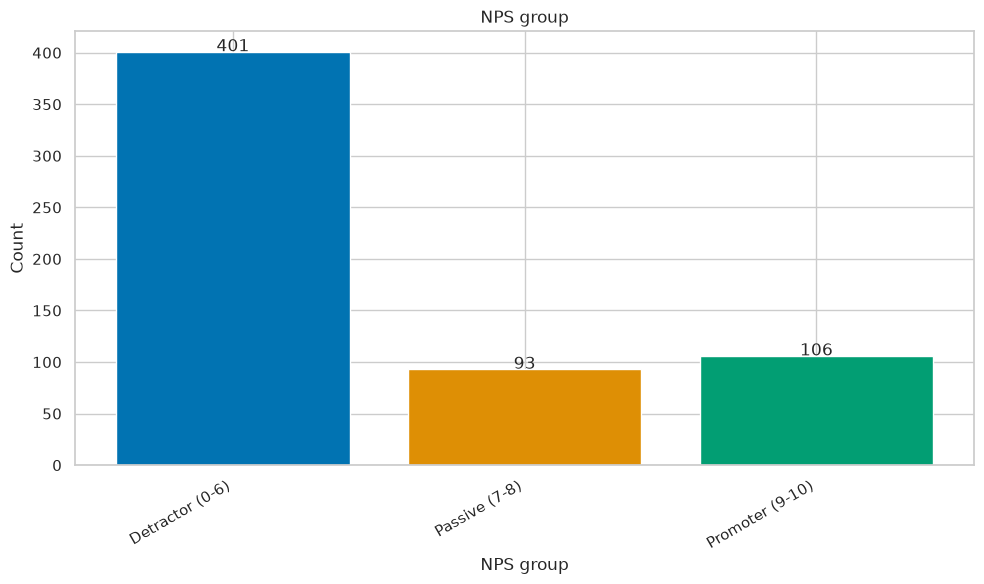

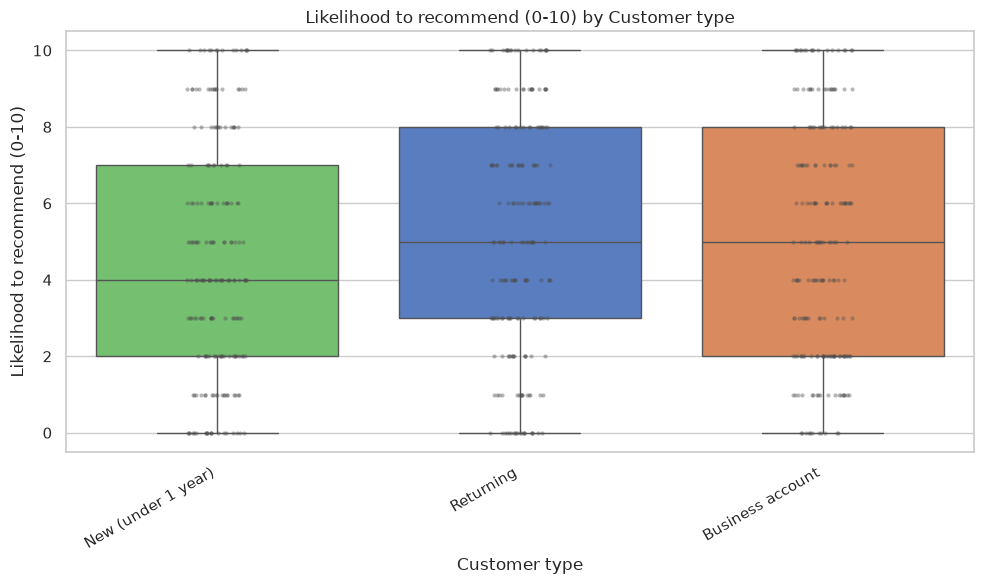

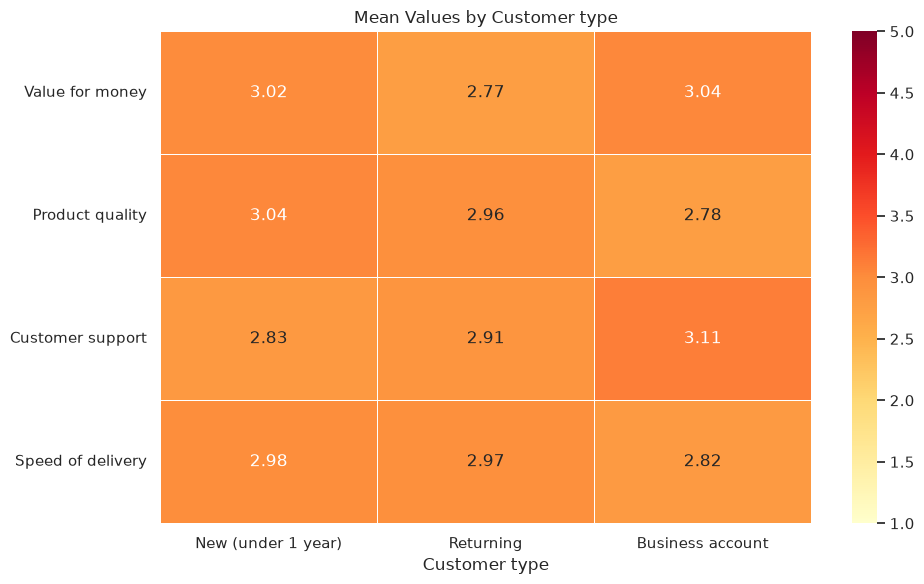

In [12]:
data.plot.bar("nps_group", palette="colorblind").plot(); plt.show()
data.plot.boxplot("nps", by="customer_type", show_points=True).plot(); plt.show()
data.plot.heatmap(attr_cols, by="customer_type", vmin=1, vmax=5).plot(); plt.show()

## 7. Deliverables: banner, Excel tables, combined report

`Report.combine()` keeps each source report as a `##` section with an anchor-linked contents list — "Sample", "Findings" and "Verbatims" can be written separately and merged in one line.

In [13]:
banner = data.tables.banner(rows=["nps_group", "overall_sat", "channel_pref"], columns=["customer_type", "product"])
banner.export_xlsx(OUT / "pulse_banner.xlsx")
data.report.crosstab("customer_type", "nps_group", pct="row").export_xlsx(OUT / "nps_by_type.xlsx")

sample = (sg.Report(title="Sample")
          .value("Completed interviews", len(data.frame))
          .add(data.report.freq("customer_type"), caption="Customer type"))
findings = (sg.Report(title="Findings", description="Net Promoter Score and drivers")
            .value("NPS", f"{nps_score:+}")
            .add(data.report.means("nps", by="customer_type"), caption="Table 1. NPS by segment")
            .add(data.plot.heatmap(attr_cols, by="customer_type", vmin=1, vmax=5),
                 caption="Figure 1. Attribute ratings by segment")
            .add(seg.round(1), caption="Table 2. Promoters, detractors and NPS by segment"))
verbatims = (sg.Report(title="Verbatims")
             .add(data.frame.loc[is_other, ["product_other"]].head(5), caption="'Other' products mentioned"))
full = sg.Report.combine([sample, findings, verbatims], title="Customer Pulse 2026 — report")
full.save(OUT / "pulse_report.md"); full.save(OUT / "pulse_report.html")
plt.close("all")
print(full.to_markdown(asset_dir=OUT)[:900])
print(sorted(p.name for p in OUT.iterdir()))

# Customer Pulse 2026 — report

## Contents
- [Sample](#sample)
- [Findings](#findings)
- [Verbatims](#verbatims)

## Sample

**Completed interviews:** 600

*Customer type*

| Value | Label | N | % | Cumulative % |
|---|---|---|---|---|
| 1 | New (under 1 year) | 204 | 34.0 | 34.0 |
| 2 | Returning | 199 | 33.2 | 67.2 |
| 3 | Business account | 197 | 32.8 | 100.0 |
|  | Total | 600 | 100.0 | 100.0 |

Variable = Customer type; N valid = 600

## Findings

*Net Promoter Score and drivers*

**NPS:** -49.2

*Table 1. NPS by segment*

| Customer type | Mean | SD | Median | N |
|---|---|---|---|---|
| New (under 1 year) | 4.539 | 3.049 | 4.0 | 204 |
| Returning | 5.101 | 3.186 | 5.0 | 199 |
| Business account | 4.98 | 3.1 | 5.0 | 197 |

F = 1.8210; p = 0.1628; N = 600; Variable = Likelihood to recommend (0-10)

![Figure 1. Attribute ratings by segment](fig_8.png)

*Figure 1. Attribute ratings b
['bundle', 'fig_8.png', 'nps_by_type.xlsx', 'pulse.db', 'pulse_banner.xlsx', 'pulse_report.html', '